In [1]:
# ==============================================================================
# CELL 0: OPUS BOOTSTRAP (SETUP, CONNECTIVITY & AESTHETICS)
# ==============================================================================
# Purpose: 1. Silence warnings for a clean output.
#          2. Mount Google Drive and connect to the Golden Master DB.
#          3. Apply the "Opus Lab" Visual Canon (Standardized Aesthetics).
# ==============================================================================

# --- 1. HYGIENE PROTOCOL ---
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
import pandas as pd
pd.options.mode.chained_assignment = None  # Silence SettingWithCopy

# --- 2. IMPORTS ---
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import sqlite3
from google.colab import drive

# --- 3. CONNECTIVITY ---
print("⏳ Mounting Google Drive...")
try:
    drive.mount('/content/drive')
    print("✅ Drive Mounted.")
except:
    print("ℹ️ Drive already mounted or running locally.")

# DEFINITIVE PATH
DB_PATH = '/content/drive/MyDrive/_Pienza/Assets/Database/opus.db'

if not os.path.exists(DB_PATH):
    print(f"🔴 CRITICAL: Database not found at {DB_PATH}")
else:
    print(f"✅ Database found: {DB_PATH}")
    db_engine = create_engine(f'sqlite:///{DB_PATH}')
    print("✅ SQL Engine Active.")

# --- 4. VISUAL CANON (OPUS LAB THEME) ---
OPUS_PURPLE = '#440154'
OPUS_TEAL   = '#21918c'
OPUS_GREY   = '#FAFAFA'
OPUS_TEXT   = '#121212'

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': OPUS_GREY,
    'axes.facecolor': OPUS_GREY,
    'text.color': OPUS_TEXT,
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif',
    'axes.titlecolor': OPUS_PURPLE,
    'axes.titleweight': 'bold',
    'figure.titlesize': 24,
    'figure.titleweight': 'bold'
})

print("✅ Visual Identity Loaded: Opus Lab (Light Mode).")
print("\n--- SYSTEM READY ---")

⏳ Mounting Google Drive...
Mounted at /content/drive
✅ Drive Mounted.
✅ Database found: /content/drive/MyDrive/_Pienza/Assets/Database/opus.db
✅ SQL Engine Active.
✅ Visual Identity Loaded: Opus Lab (Light Mode).

--- SYSTEM READY ---


# 📉 **Campaña Analítica: Convergencia a la Media Intra-Sesión**

### Fase 1: Preparando el Terreno Temporal

✅ Datos cargados y ordenados. Shape: (4765, 4)



### Fase 2: Forjando las Métricas de Convergencia

✅ Métricas de convergencia calculadas.



### Fase 3: ¿Cuándo se estabiliza la sesión?

En promedio, una sesión converge después de 50.6 ofertas.


/tmp/ipython-input-1695966387.py:61: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  convergence_points = df_conv.groupby('session_fk').apply(find_convergence_point).dropna()


,session_fk,offers_to_converge,main_category
0,SID0001,29,UberX
1,SID0002,39,UberX
2,SID0003,57,UberX
3,SID0004,70,UberX
4,SID0005-1,9,UberX



### Fase 4: Visualizando la Convergencia por Categoría

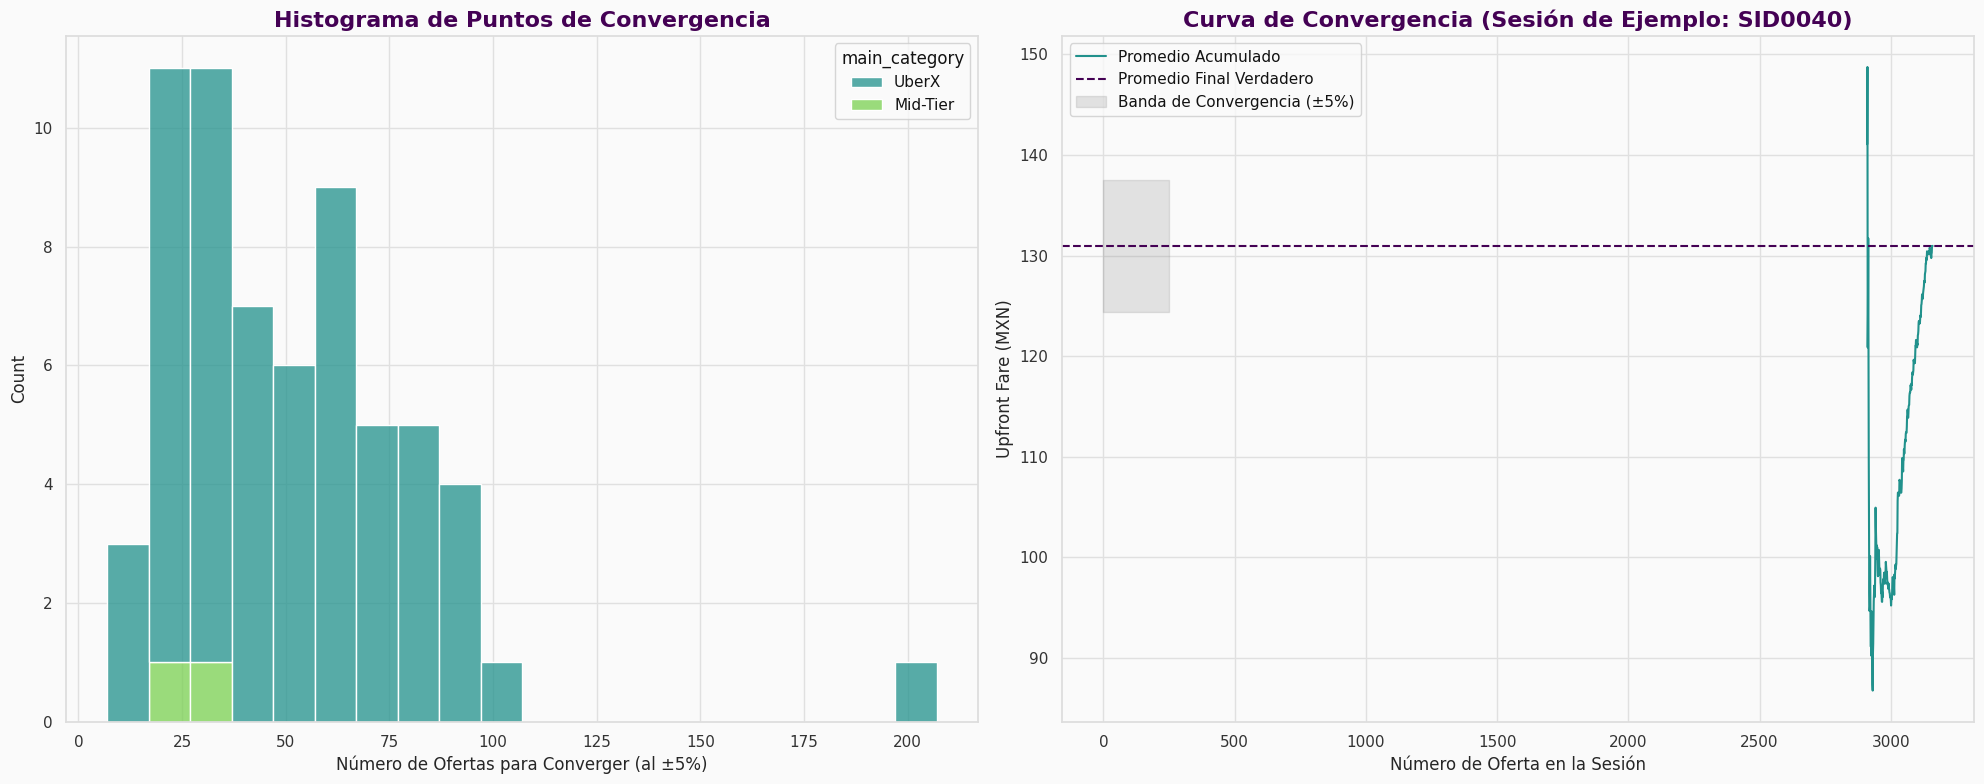

In [2]:
# ==============================================================================
# CELL: CAMPAÑA DE CONVERGENCIA A LA MEDIA
# ==============================================================================
from IPython.display import display, Markdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

display(Markdown("# 📉 **Campaña Analítica: Convergencia a la Media Intra-Sesión**"))

# --- FASE 1: INGESTA Y PREPARACIÓN ---
display(Markdown("### Fase 1: Preparando el Terreno Temporal"))
query = """
SELECT o.session_fk, o.offer_timestamp, o.upfront_fare, pc.category_name
FROM offers o
LEFT JOIN product_category pc ON o.product_category_fk = pc.product_category_id
WHERE o.upfront_fare IS NOT NULL
ORDER BY o.session_fk, o.offer_timestamp
"""
df_conv = pd.read_sql(query, db_engine)
print(f"✅ Datos cargados y ordenados. Shape: {df_conv.shape}")

# Simplificar categorías
def simplify_category(cat):
    if pd.isna(cat): return 'Other'
    cat_lower = cat.lower()
    if 'uberx' in cat_lower: return 'UberX'
    elif 'comfort' in cat_lower or 'business' in cat_lower: return 'Mid-Tier'
    elif 'black' in cat_lower: return 'Black'
    else: return 'Other'
df_conv['simplified_category'] = df_conv['category_name'].apply(simplify_category)


# --- FASE 2: INGENIERÍA DE MÉTRICAS DE CONVERGENCIA ---
display(Markdown("\n### Fase 2: Forjando las Métricas de Convergencia"))

# 1. Calcular el promedio final "verdadero" para cada sesión
df_conv['session_mean_fare'] = df_conv.groupby('session_fk')['upfront_fare'].transform('mean')

# 2. Calcular el promedio acumulado expansivo para cada oferta
df_conv['cumulative_avg_fare'] = df_conv.groupby('session_fk')['upfront_fare'].expanding().mean().reset_index(level=0, drop=True)

# 3. Calcular el error de convergencia como porcentaje
df_conv['convergence_error_%'] = ((df_conv['cumulative_avg_fare'] / df_conv['session_mean_fare']) - 1) * 100
print("✅ Métricas de convergencia calculadas.")


# --- FASE 3: MEDICIÓN EMPÍRICA DEL PUNTO DE CONVERGENCIA ---
display(Markdown("\n### Fase 3: ¿Cuándo se estabiliza la sesión?"))
convergence_threshold = 5 # Definimos "convergencia" como estar dentro del +/- 5%

def find_convergence_point(session_df):
    converged_mask = session_df['convergence_error_%'].abs() <= convergence_threshold
    # Encontrar la primera vez que se cumple y se mantiene
    for i in range(len(session_df)):
        if converged_mask.iloc[i:].all():
            return i + 1 # Devolvemos el número de oferta (índice + 1)
    return np.nan # No convergió

convergence_points = df_conv.groupby('session_fk').apply(find_convergence_point).dropna()
convergence_points_df = convergence_points.reset_index(name='offers_to_converge')

# Unir con la categoría principal de la sesión
session_category = df_conv.groupby('session_fk')['simplified_category'].agg(lambda x: x.mode()[0])
convergence_points_df = convergence_points_df.merge(session_category.rename('main_category'), on='session_fk')

print(f"En promedio, una sesión converge después de {convergence_points_df['offers_to_converge'].mean():.1f} ofertas.")
display(convergence_points_df.head())

# --- FASE 4: VISUALIZACIÓN Y SEGMENTACIÓN ---
display(Markdown("\n### Fase 4: Visualizando la Convergencia por Categoría"))
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Gráfico 1: Histograma de puntos de convergencia
sns.histplot(data=convergence_points_df, x='offers_to_converge', hue='main_category',
             multiple='stack', palette={'UberX':OPUS_TEAL, 'Mid-Tier':'#7AD151', 'Black':OPUS_PURPLE}, ax=axes[0], bins=20)
axes[0].set_title('Histograma de Puntos de Convergencia', fontsize=16, fontweight='bold', color=OPUS_PURPLE)
axes[0].set_xlabel('Número de Ofertas para Converger (al ±5%)')

# Gráfico 2: Curva de convergencia de una sesión de ejemplo
sample_session = df_conv['session_fk'].value_counts().idxmax() # La sesión con más ofertas
df_sample = df_conv[df_conv['session_fk'] == sample_session]

axes[1].plot(df_sample['cumulative_avg_fare'], label='Promedio Acumulado', color=OPUS_TEAL)
axes[1].axhline(df_sample['session_mean_fare'].iloc[0], color=OPUS_PURPLE, linestyle='--', label='Promedio Final Verdadero')
axes[1].fill_between(range(len(df_sample)),
                   df_sample['session_mean_fare'].iloc[0] * (1 - convergence_threshold/100),
                   df_sample['session_mean_fare'].iloc[0] * (1 + convergence_threshold/100),
                   color='gray', alpha=0.2, label='Banda de Convergencia (±5%)')

axes[1].set_title(f'Curva de Convergencia (Sesión de Ejemplo: {sample_session})', fontsize=16, fontweight='bold', color=OPUS_PURPLE)
axes[1].set_xlabel('Número de Oferta en la Sesión')
axes[1].set_ylabel('Upfront Fare (MXN)')
axes[1].legend()

plt.tight_layout()
plt.show()

# 📉 **ANÁLISIS DE CONVERGENCIA: La Ilusión de la "Lectura Rápida"**

Esta investigación fue diseñada para probar una hipótesis crítica: *"¿Puedo 'leer' la calidad de una sesión con solo las primeras ofertas?"* La respuesta, según los datos, es un **no rotundo**.

### **1. El Veredicto del Histograma**
*   **Observación:** El "Histograma de Puntos de Convergencia" (izquierda) muestra que la mayoría de las sesiones no convergen hasta después de **25, 50, o incluso 75 ofertas**. El promedio de **50.6 ofertas** para alcanzar una estimación estable (dentro del ±5%) de la tarifa media de la sesión es una métrica brutalmente honesta.
*   **`Insight`:** El mercado es **mucho más volátil** de lo que la intuición sugiere. Las primeras 10-15 ofertas no son una muestra representativa; pueden ser anormalmente buenas o malas, creando una falsa impresión de la "calidad del día".

### **2. La Autopsia de la Sesión de Ejemplo (`SID0040`)**
*   **Observación:** La "Curva de Convergencia" (derecha) es la prueba visual perfecta. Durante cientos de ofertas, el promedio acumulado (verde) se mantiene muy por debajo del promedio final (morado). La sesión *parecía* terrible. Luego, hacia el final, una serie de ofertas de alto valor causan que el promedio se dispare y finalmente converja.
*   **`Insight`:** Este es el **efecto de los `outliers` de alto valor** o los cambios de régimen del mercado (`surge` que se activa tarde). Una sesión puede ser "salvada" en sus últimas horas. Abandonar una sesión prematuramente basándose en los promedios iniciales es una estrategia sub-óptima que te haría perder estas oportunidades tardías.

---
### **Conclusión Estratégica (La Nueva Heurística)**

**La Hipótesis Original queda invalidada.** El `upfront_fare` promedio intra-sesión NO es un indicador estable a corto plazo.

**La Nueva Política Operativa (Basada en Datos):**
*   **No confíes en los promedios a corto plazo.** La "suerte" (o mala suerte) inicial de una sesión no predice su resultado final.
*   La decisión de continuar o abandonar una sesión no debe basarse en la tarifa promedio de las primeras 20 ofertas, sino en **variables de mercado más robustas** (como las `offer_density` que ya hemos diseñado) o en el cumplimiento de una **meta de tiempo o ganancias totales**.

Este análisis ha destruido una heurística potencialmente costosa y la ha reemplazado con una comprensión más profunda y estadísticamente validada de la volatilidad del mercado. Esto es `Opus` en su máxima expresión.